**Overview**  
This notebook describes Cc prediction with torch-molecule models. There are 9 DL models for properties predction (mostly, different types of GNNs). The structure of notebook resembles the one, employing shallow methods. First, we assess model performance and select the best one 

In [15]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

import torch
from torch_molecule import GREAMolecularPredictor
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

ImportError: cannot import name 'root_mean_squared_error' from 'sklearn.metrics' (C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\metrics\__init__.py)

In [4]:
from torch_molecule import GREAMolecularPredictor, BFGNNMolecularPredictor, SGIRMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor, GNNMolecularPredictor, LSTMMolecularPredictor


We import dataset, containing Cc values vs SMILES of molecules

In [5]:
data_extended = pd.read_csv('Data_extended.csv', usecols=[1,2])

In [13]:
def calculate_to_score(estimator, dataset):
    train, test = train_test_split(dataset, random_state=0, train_size=0.75)
    train, val = train_test_split(train, random_state=0, train_size=0.12)
    
    est = estimator
    best_estimator  = est.autofit(X_train = list(train['SMILES']),
                                        y_train = list(train['Cc ']),
                                        X_val = list(val['SMILES']),
                                        y_val = list(val['Cc ']), n_trials = 10)    
    
    predictions= best_estimator.predict(list(test['SMILES']))['prediction']
    predictions_train = best_estimator.predict(list(train['SMILES']))['prediction']
    scores['Estimator'].append(est.model_name)
    scores['R2_test'].append(r2_score(test['Cc '], predictions))
    scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
    scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
    scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
    scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
    scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

In [14]:
scores = { 'Estimator': [],  'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }
trained_models = {}

Let's initialize scores dictionary and test function with Logistic Regression

In [15]:
models = [GREAMolecularPredictor, BFGNNMolecularPredictor, GRINMolecularPredictor, DIRMolecularPredictor, SSRMolecularPredictor, IRMMolecularPredictor, RPGNNMolecularPredictor,GNNMolecularPredictor]

In [8]:
train, test = train_test_split(data_extended, random_state=0, train_size=0.75)
train, val = train_test_split(train, random_state=0, train_size=0.12)

In [9]:
model = BFGNNMolecularPredictor(device='cuda:0')

In [10]:
best_estimator  = model.autofit(X_train = list(train['SMILES']),
                                        y_train = list(train['Cc ']),
                                        X_val = list(val['SMILES']),
                                        y_val = list(val['Cc ']), n_trials = 10)    

In [16]:
for model in tqdm(models):
    calculate_to_score(model(device = 'cuda:0'), dataset = data_extended)

 25%|█████████████████████                                                               | 2/8 [01:09<03:27, 34.57s/it]C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\grin\modeling_grin.py:234: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\grin\modeling_grin.py:260: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\grin\modeling_grin.py:414: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\grin\modeling_grin.py:234: UserWarning: 'data.DataLoader' is deprecated, use

In [17]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,0.606801,0.576926,0.508007,0.472176,0.363806,0.292879
1,BFGNNMolecularPredictor,0.318890,0.759316,0.663313,0.423864,0.380091,0.282491
2,GRINMolecularPredictor,0.562690,0.608427,0.555947,0.850408,0.193678,0.141146
3,DIRMolecularPredictor,0.544686,0.620825,0.503152,0.546189,0.337336,0.268439
4,SSRMolecularPredictor,0.768337,0.442835,0.390895,0.254005,0.432507,0.260814
5,IRMMolecularPredictor,0.507360,0.645771,0.516253,-0.538087,0.621035,0.571276
6,RPGNNMolecularPredictor,0.408204,0.707782,0.635959,-0.976758,0.704048,0.575428
7,GNNMolecularPredictor,0.872676,0.328298,0.305386,0.354723,0.402252,0.348621


Two models:
1. SGIRMolecular predictor
2. LSTMMolecular predictor

Must be done and loaded to scores manually. First we start with SGIRMolecular predictor, which requires the use of unlabelled SMILES

In [18]:
sgir = SGIRMolecularPredictor()
train, test = train_test_split(data_extended, random_state=0, train_size=0.75)
val, unlb = train_test_split(data_extended, random_state=0, train_size=0.5)

In [19]:
sgir.autofit(X_train = list(train['SMILES']),y_train = list(train['Cc ']),
             X_val = list(val['SMILES']),y_val  =list(val['Cc ']), X_unlbl = list(unlb['SMILES']))

In [20]:
predictions= sgir.predict(list(test['SMILES']))['prediction']
predictions_train = sgir.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(sgir.model_name)
scores['R2_test'].append(r2_score(test['Cc '], predictions))
scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

Then we perform the same operations with LSTM predictor, which requires the use of target inout as Numpy array, not list

In [21]:
train, test = train_test_split(data_extended, random_state=0, train_size=0.75)
val, test = train_test_split(test, random_state=0, train_size=0.5)

In [22]:
lstm = LSTMMolecularPredictor()

In [23]:
lstm.autofit(X_train = list(train['SMILES']),
             y_train = np.array(train['Cc ']),
             X_val = list(val['SMILES']),
             y_val = np.array(val['Cc ']))

In [24]:
predictions= lstm.predict(list(test['SMILES']))['prediction']
predictions_train = lstm.predict(list(train['SMILES']))['prediction']

scores['Estimator'].append(lstm.model_name)
scores['R2_test'].append(r2_score(test['Cc '], predictions))
scores['R2_train'].append(r2_score(train['Cc '], predictions_train))
        
scores['RMSE_test'].append(root_mean_squared_error(test['Cc '], predictions))
scores['RMSE_train'].append(root_mean_squared_error(train['Cc '], predictions_train))

        
scores['MAE_test'].append(mean_absolute_error(test['Cc '], predictions))
scores['MAE_train'].append(mean_absolute_error(train['Cc '], predictions_train))

In [25]:
pd.DataFrame(scores)

,Estimator,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,GREAMolecularPredictor,0.606801,0.576926,0.508007,0.472176,0.363806,0.292879
1,BFGNNMolecularPredictor,0.318890,0.759316,0.663313,0.423864,0.380091,0.282491
2,GRINMolecularPredictor,0.562690,0.608427,0.555947,0.850408,0.193678,0.141146
3,DIRMolecularPredictor,0.544686,0.620825,0.503152,0.546189,0.337336,0.268439
4,SSRMolecularPredictor,0.768337,0.442835,0.390895,0.254005,0.432507,0.260814
5,IRMMolecularPredictor,0.507360,0.645771,0.516253,-0.538087,0.621035,0.571276
6,RPGNNMolecularPredictor,0.408204,0.707782,0.635959,-0.976758,0.704048,0.575428
7,GNNMolecularPredictor,0.872676,0.328298,0.305386,0.354723,0.402252,0.348621
8,SGIRMolecularPredictor,-0.451805,1.108583,0.595935,0.999211,0.031285,0.023781
9,LSTMMolecularPredictor,0.286202,0.832046,0.667907,0.790897,0.509451,0.293635


In [26]:
with open('scores_extended_torch.pickle', 'wb') as output:
    pickle.dump(scores, output)

As we can see, SSR model have the best generalization performace (highest R2, lowest RMSE - about 0.36 lower, than for the best shallow model). We will perform hyperparameter tuning for SGIR using *hyperopt* package

Let's finally fit the best estimator and plot predicted values vs true ones

In [73]:
train, test = train_test_split(data_extended, random_state=0, train_size=0.75)

In [74]:
ssr_auto = SSRMolecularPredictor(device='cuda:0')

In [75]:
ssr_auto.autofit(X_train = list(train['SMILES']),
               y_train=list(train['Cc ']))

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(
C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\L

RMSE of predictor for test set is 1.2446541238127236
R2 value of predictor for test set is -3.971014550676329
MAE value for test set is 0.762396003405253


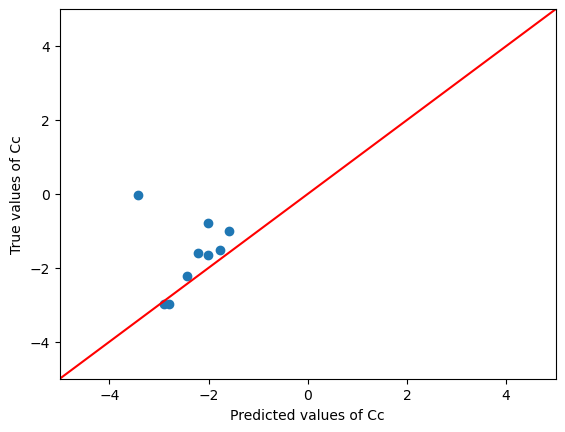

In [76]:
predictions = ssr_auto.predict(list(test['SMILES']))

plt.plot(predictions['prediction'], test['Cc '], 'o')
plt.plot([-5, 5], [-5,5], 'r')
plt.xlabel('Predicted values of Cc')
plt.ylabel('True values of Cc')
plt.xlim(-5, 5)
plt.ylim(-5, 5)

print('RMSE of predictor for test set is {}'.format(root_mean_squared_error(predictions['prediction'], test['Cc '])))
print('R2 value of predictor for test set is {}'.format(r2_score(predictions['prediction'], test['Cc '])))
print('MAE value for test set is {}'.format(mean_absolute_error(predictions['prediction'], test['Cc '])))

In [83]:
parameters_optimal = ssr_auto.get_params()

In [80]:
print(parameters_optimal)

{'num_task': 1, 'task_type': 'regression', 'num_layer': 4, 'hidden_size': 287, 'gnn_type': 'gin-virtual', 'drop_ratio': 0.07869152715277741, 'norm_layer': 'batch_norm', 'graph_pooling': 'mean', 'augmented_feature': ['maccs', 'morgan'], 'batch_size': 128, 'epochs': 500, 'learning_rate': 0.005813958007324512, 'weight_decay': 4.466190537579589e-07, 'patience': 50, 'grad_clip_value': None, 'loss_criterion': L1Loss(), 'evaluate_name': 'mae', 'evaluate_criterion': <function mean_absolute_error at 0x00000261A5D10A40>, 'evaluate_higher_better': False, 'use_lr_scheduler': False, 'scheduler_factor': 0.34228582494464943, 'scheduler_patience': 5, 'fitting_epoch': 89, 'fitting_loss': [28.838871002197266, 19.814054489135742, 16.39473533630371, 15.30178165435791, 14.357309341430664, 13.428070068359375, 12.980795860290527, 12.645362854003906, 12.676287651062012, 12.682387351989746, 12.171624183654785, 11.846322059631348, 11.886762619018555, 10.982328414916992, 11.227147102355957, 11.48542308807373, 10

In [91]:
def manual_cross_val_predict(cv, X, y, estimator, random_state = 0, shuffle = True):
    X = X.reset_index(drop = True)
    y = y.reset_index(drop = True)
    y_pred = np.empty_like(y)
    kfold = KFold(n_splits=cv, shuffle = True, random_state = random_state)
    for i, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        print(i)
        model = estimator
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        
        model.fit(X_train = list(X_train), y_train = list(y_train))
        y_pred[test_idx] = model.predict(list(X_test))['prediction'].squeeze()
    return y_pred

In [92]:
cross_val_predictions = manual_cross_val_predict(cv = 5, X = train['SMILES'], y = train['Cc '], 
                                                 estimator = SSRMolecularPredictor(device = 'cuda:0').set_params(**parameters_optimal),
                                                 )

0


C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(


1


C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(


2


C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(


3


C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(


4


C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\torch_molecule\predictor\gnn\modeling_gnn.py:559: UserWarning: No validation set provided. Using training set for validation. This may lead to overfitting.
  warnings.warn(


In [93]:
print('RMSE for CV is {}'.format(root_mean_squared_error(cross_val_predictions, train['Cc '])))
print('R2 value for for CV is {}'.format(r2_score(cross_val_predictions, train['Cc '])))
print('MAE value for CV is {}'.format(mean_absolute_error(cross_val_predictions, train['Cc '])))

RMSE for CV is 1.073165196330584
R2 value for for CV is 0.32840807379990966
MAE value for CV is 0.7957567286752738
